In [ ]:
# If you are running on Google Colab, UNCOMMENT this block.
'''
# ── Google Drive mount ────────────────────────────────────────────────────────
from google.colab import drive
drive.mount("/content/drive")
'''

Mounted at /content/drive


In [ ]:
# ==============================================================================
# IMPORTS, CONSTANTS, PATHS
# ==============================================================================

import os
import sys
import json
import time
import random
import warnings

from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple, Any, Optional

import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt

from tqdm import tqdm, trange
from scipy.stats import mannwhitneyu

import torch
import torch.nn as nn

import gymnasium as gym

warnings.filterwarnings("ignore")

try:

    from sklearn.ensemble import (
        RandomForestClassifier
    )

    _SKLEARN_OK = True

except ImportError:

    _SKLEARN_OK = False

    print(
        "[warn] sklearn unavailable"
    )

# ------------------------------------------------------------------
# Experiment constants
# ------------------------------------------------------------------

MASTER_SEED = 42

# for faster run NUM_RUNS=1, EPISODE_BUDGET= 100. for paper results replication, set (NUM_RUNS=10, EPISODE_BUDGET= 1500)
NUM_RUNS = 1
EPISODE_BUDGET = 100

BASE_SEED_START = 5000

R_FAIL_PEND = -350.0

COS_BOUNDS = (-1.0, 1.0)
SIN_BOUNDS = (-1.0, 1.0)
THDOT_BOUNDS = (-8.0, 8.0)

NR_RL_SIGMA_ACTION = 0.3

random.seed(MASTER_SEED)
np.random.seed(MASTER_SEED)

# ------------------------------------------------------------------
# Paths
# ------------------------------------------------------------------

DRIVE_ROOT = Path(
    "/content/drive/MyDrive/"
    "mbrl-testing-frameworks-empirical-study"
)

AGENT_ROOT = (
    DRIVE_ROOT
    / "agents"
    / "pets"
    / "pendulum"
    / "pets_pendulum_base"
)

RESULTS_DIR = (
    DRIVE_ROOT
    / "results"
    / "pendulum_unified_tcp_full"
)

FIGS_DIR = RESULTS_DIR / "figs"
TABLES_DIR = RESULTS_DIR / "tables"
RAW_DIR = RESULTS_DIR / "raw"

for d in [
    RESULTS_DIR,
    FIGS_DIR,
    TABLES_DIR,
    RAW_DIR,
]:
    d.mkdir(
        parents=True,
        exist_ok=True,
    )

print("Paths ready")
print("AGENT_ROOT :", AGENT_ROOT)
print("RESULTS_DIR:", RESULTS_DIR)

Paths ready
AGENT_ROOT : /content/drive/MyDrive/mbrl-testing-frameworks-empirical-study/agents/pets/pendulum/pets_pendulum_base
RESULTS_DIR: /content/drive/MyDrive/mbrl-testing-frameworks-empirical-study/results/pendulum_unified_tcp_full


In [ ]:
# ==============================================================================
# PLOT CONFIG
# ==============================================================================

mpl.rcParams.update({

    "figure.figsize": (3.4, 2.4),

    "font.size": 9,

    "axes.titlesize": 9,
    "axes.labelsize": 9,

    "legend.fontsize": 8,

    "xtick.labelsize": 8,
    "ytick.labelsize": 8,

    "axes.linewidth": 0.8,
    "lines.linewidth": 1.5,
    "grid.linewidth": 0.5,

    "axes.spines.top": False,
    "axes.spines.right": False,

    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

plt.style.use("default")

TCP_COLOR_MAP = {

    "FIFO": "#4D4D4D",

    "Random": "#9E9E9E",

    "EnsembleVariance":
        "#80B1D3",

    "CEMEntropy":
        "#1F77B4",
}

FW_COLOR_MAP = {

    "Indago":
        "#40E0D0",

    "STARLA":
        "#069AF3",

    "QD-Testing":
        "#580F41",

    "RLMutation":
        "#41AB5D",

    "MDPFuzz":
        "#984EA3",

    "NR-RL":
        "#E41A1C",
}

def _slug(s: str):

    return (
        s
        .replace("/", "_")
        .replace(" ", "_")
        .replace(":", "_")
    )

print("Plot configuration ready")

Plot configuration ready


In [ ]:
# ==============================================================================
# LOAD PETS AGENT
# ==============================================================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

assert AGENT_ROOT.is_dir(), (
    f"Agent bundle not found: "
    f"{AGENT_ROOT}"
)

CKPT_DIR = (
    AGENT_ROOT
    / "checkpoint"
)

assert CKPT_DIR.is_dir(), (
    f"Checkpoint dir missing: "
    f"{CKPT_DIR}"
)

with open(
    AGENT_ROOT / "config.json",
    "r",
) as f:

    CONFIG_JSON = json.load(f)

OBS_DIM = CONFIG_JSON["obs_dim"]

ACT_DIM = CONFIG_JSON["act_dim"]

ACT_LOW = float(
    CONFIG_JSON["action_low"]
)

ACT_HIGH = float(
    CONFIG_JSON["action_high"]
)

PEND_MAX_STEPS = (
    CONFIG_JSON["training"]
    ["episode_len"]
)

@dataclass
class PETSConfig:

    ensemble_size: int

    hidden_dim: int

    horizon: int

    pop_size: int

    elite_frac: float

    num_iters: int

    action_low: float

    action_high: float

    init_std: float


PETS_CFG = PETSConfig(
    **CONFIG_JSON["pets_cfg"]
)


class DynamicsNet(nn.Module):

    def __init__(
        self,
        in_dim,
        out_dim,
        hidden_dim,
    ):
        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(
                in_dim,
                hidden_dim,
            ),

            nn.ReLU(),

            nn.Linear(
                hidden_dim,
                hidden_dim,
            ),

            nn.ReLU(),

            nn.Linear(
                hidden_dim,
                out_dim,
            ),
        )

    def forward(
        self,
        x,
    ):
        return self.net(x)


class EnsembleDynamics(
    nn.Module
):

    def __init__(
        self,
        in_dim,
        out_dim,
        ensemble_size,
        hidden_dim,
    ):

        super().__init__()

        self.ensemble_size = (
            ensemble_size
        )

        self.models = (
            nn.ModuleList([
                DynamicsNet(
                    in_dim,
                    out_dim,
                    hidden_dim,
                )
                for _ in range(
                    ensemble_size
                )
            ])
        )

    def predict_delta(
        self,
        x,
        model_idx=None,
    ):

        if model_idx is not None:

            return (
                self.models[
                    model_idx
                ](x)
            )

        return torch.stack(
            [
                m(x)
                for m in self.models
            ],
            dim=0,
        )


_ckpt = torch.load(
    CKPT_DIR / "ensemble.pt",
    map_location=device,
)

MODEL = EnsembleDynamics(

    _ckpt["in_dim"],

    _ckpt["out_dim"],

    _ckpt["ensemble_size"],

    _ckpt["hidden_dim"],
).to(device)

for m, sd in zip(
    MODEL.models,
    _ckpt["state_dicts"],
):
    m.load_state_dict(sd)

MODEL.eval()

print(
    f"✓ PETS loaded "
    f"({MODEL.ensemble_size} models)"
)

print(
    f"device = {device}"
)

✓ PETS loaded (5 models)
device = cpu


In [ ]:
# ==============================================================================
# PENDULUM UTILITIES
# ==============================================================================

def make_env(
    seed=None,
):

    env = gym.make(
        "Pendulum-v1"
    )

    if seed is not None:

        env.reset(
            seed=int(seed)
        )

    return env


def reset_env(
    env,
    seed=None,
):

    obs, _ = (
        env.reset(
            seed=int(seed)
        )
        if seed is not None
        else env.reset()
    )

    return obs.astype(
        np.float32
    )


def step_env(
    env,
    action,
):

    obs, rew, terminated, truncated, info = (
        env.step(action)
    )

    return (
        obs.astype(np.float32),
        float(rew),
        bool(
            terminated
            or truncated
        ),
        info,
    )


def pendulum_reward_torch(
    state,
    action,
):

    cos_th = state[..., 0]
    sin_th = state[..., 1]
    thdot = state[..., 2]

    theta = torch.atan2(
        sin_th,
        cos_th,
    )

    cost = (

        theta ** 2

        + 0.1 * thdot ** 2

        + 0.001
        * (
            action[..., 0] ** 2
        )
    )

    return -cost


def clamp_obs(
    obs,
):

    obs = (
        obs.copy()
        .astype(np.float32)
    )

    obs[0] = np.clip(
        obs[0],
        *COS_BOUNDS
    )

    obs[1] = np.clip(
        obs[1],
        *SIN_BOUNDS
    )

    obs[2] = np.clip(
        obs[2],
        *THDOT_BOUNDS
    )

    return obs


def obs_from_seed(
    seed,
):

    env = make_env()

    obs = reset_env(
        env,
        seed=int(seed),
    )

    env.close()

    return obs


print("✓ Pendulum utilities ready")

✓ Pendulum utilities ready


In [ ]:
# ==============================================================================
# PETS CONTROLLER
# ==============================================================================

class PETSController:

    def __init__(
        self,
        model,
        cfg,
        obs_dim,
        act_dim,
    ):

        self.model = model
        self.cfg = cfg

        self.obs_dim = obs_dim
        self.act_dim = act_dim

    def plan(
        self,
        obs_np,
    ):

        cfg = self.cfg

        horizon = cfg.horizon

        pop_size = cfg.pop_size

        elite_size = int(
            pop_size
            * cfg.elite_frac
        )

        mean = np.zeros(
            (
                horizon,
                self.act_dim,
            ),
            dtype=np.float32,
        )

        std = (
            np.ones(
                (
                    horizon,
                    self.act_dim,
                ),
                dtype=np.float32,
            )
            * cfg.init_std
        )

        obs_t = (
            torch.from_numpy(obs_np)
            .float()
            .to(device)
        )

        self.model.eval()

        with torch.no_grad():

            for _ in range(
                cfg.num_iters
            ):

                actions = np.random.normal(
                    mean,
                    std,
                    size=(
                        pop_size,
                        horizon,
                        self.act_dim,
                    ),
                )

                actions = np.clip(
                    actions,
                    cfg.action_low,
                    cfg.action_high,
                )

                returns = (
                    self._evaluate(
                        obs_t,
                        actions,
                    )
                )

                elite = actions[
                    np.argsort(
                        returns
                    )[-elite_size:]
                ]

                mean = elite.mean(
                    axis=0
                )

                std = (
                    elite.std(
                        axis=0
                    )
                    + 1e-6
                )

        return np.clip(
            mean[0],
            cfg.action_low,
            cfg.action_high,
        ).astype(np.float32)

    def plan_with_cem_distribution(
        self,
        obs_np,
    ):

        cfg = self.cfg

        horizon = cfg.horizon

        pop_size = cfg.pop_size

        elite_size = int(
            pop_size
            * cfg.elite_frac
        )

        mean = np.zeros(
            (
                horizon,
                self.act_dim,
            ),
            dtype=np.float32,
        )

        std = (
            np.ones(
                (
                    horizon,
                    self.act_dim,
                ),
                dtype=np.float32,
            )
            * cfg.init_std
        )

        obs_t = (
            torch.from_numpy(obs_np)
            .float()
            .to(device)
        )

        self.model.eval()

        with torch.no_grad():

            for _ in range(
                cfg.num_iters
            ):

                actions = np.random.normal(
                    mean,
                    std,
                    size=(
                        pop_size,
                        horizon,
                        self.act_dim,
                    ),
                )

                actions = np.clip(
                    actions,
                    cfg.action_low,
                    cfg.action_high,
                )

                returns = (
                    self._evaluate(
                        obs_t,
                        actions,
                    )
                )

                elite = actions[
                    np.argsort(
                        returns
                    )[-elite_size:]
                ]

                mean = elite.mean(
                    axis=0
                )

                std = (
                    elite.std(
                        axis=0
                    )
                    + 1e-6
                )

        action = np.clip(
            mean[0],
            cfg.action_low,
            cfg.action_high,
        ).astype(np.float32)

        return (
            action,
            mean,
            std,
        )

    def _evaluate(
        self,
        obs_t,
        actions_np,
    ):

        pop_size, horizon, _ = (
            actions_np.shape
        )

        returns = np.zeros(
            pop_size,
            dtype=np.float32,
        )

        model_idx = np.random.randint(
            self.model.ensemble_size
        )

        states = (
            obs_t.unsqueeze(0)
            .repeat(
                pop_size,
                1,
            )
        )

        with torch.no_grad():

            for t in range(
                horizon
            ):

                act_t = (
                    torch.from_numpy(
                        actions_np[:, t]
                    )
                    .float()
                    .to(device)
                )

                x = torch.cat(
                    [
                        states,
                        act_t,
                    ],
                    dim=-1,
                )

                delta = (
                    self.model
                    .predict_delta(
                        x,
                        model_idx,
                    )
                )

                states = (
                    states
                    + delta
                )

                returns += (
                    pendulum_reward_torch(
                        states,
                        act_t,
                    )
                    .cpu()
                    .numpy()
                )

        return returns


CONTROLLER = PETSController(
    MODEL,
    PETS_CFG,
    OBS_DIM,
    ACT_DIM,
)

print("✓ PETS controller ready")

✓ PETS controller ready


In [ ]:
# ==============================================================================
# FULL PETS SIGNAL EXTRACTION
# ==============================================================================

def compute_ensemble_variance(
    obs_np: np.ndarray
) -> float:

    obs = torch.from_numpy(
        obs_np.astype(np.float32)
    ).float().to(device)

    _, cem_mean, _ = (
        CONTROLLER.plan_with_cem_distribution(
            obs_np
        )
    )

    horizon = PETS_CFG.horizon

    ensemble_predictions = []

    with torch.no_grad():

        for model_idx in range(
            MODEL.ensemble_size
        ):

            state = obs.unsqueeze(0)

            traj = []

            for t in range(horizon):

                action_t = torch.from_numpy(
                    cem_mean[t].reshape(1, -1)
                ).float().to(device)

                x = torch.cat(
                    [state, action_t],
                    dim=-1,
                )

                delta = MODEL.predict_delta(
                    x,
                    model_idx=model_idx,
                )

                state = state + delta

                traj.append(
                    state.squeeze(0)
                )

            traj = torch.stack(
                traj,
                dim=0,
            )

            ensemble_predictions.append(
                traj
            )

    ensemble_predictions = torch.stack(
        ensemble_predictions,
        dim=0,
    )

    variance = torch.var(
        ensemble_predictions,
        dim=0,
        unbiased=False,
    ).mean()

    return float(
        variance.item()
    )


def compute_cem_entropy(
    obs_np: np.ndarray
) -> float:

    _, _, final_std_all_steps = (
        CONTROLLER.plan_with_cem_distribution(
            obs_np
        )
    )

    entropy = 0.5 * np.log(
        2.0
        * np.pi
        * np.e
        * (
            final_std_all_steps ** 2
            + 1e-12
        )
    )

    return float(
        np.mean(entropy)
    )


# ==============================================================================
# STATE NOVELTY
# ==============================================================================

def compute_state_centroid(
    test_pool
):

    obs_list = []

    for t in test_pool:

        if "_obs_override" in t:

            obs = np.asarray(
                t["_obs_override"],
                dtype=np.float32,
            )

        else:

            obs = obs_from_seed(
                int(t["seed"])
            )

        obs_list.append(obs)

    return np.mean(
        obs_list,
        axis=0,
    )


def attach_state_novelty(
    test_pool
):

    centroid = (
        compute_state_centroid(
            test_pool
        )
    )

    for t in test_pool:

        if "_obs_override" in t:

            obs = np.asarray(
                t["_obs_override"],
                dtype=np.float32,
            )

        else:

            obs = obs_from_seed(
                int(t["seed"])
            )

        novelty = np.linalg.norm(
            obs - centroid
        )

        t["StateNovelty"] = float(
            novelty
        )

    return test_pool


# ==============================================================================
# MODEL ERROR
# ==============================================================================

def compute_model_error(
    obs_np
):

    env = make_env()

    state = pendulum_state_from_obs(
        obs_np
    )

    env.reset()

    env.unwrapped.state = (
        state.copy()
    )

    obs_real = np.array(
        [
            np.cos(state[0]),
            np.sin(state[0]),
            state[1],
        ],
        dtype=np.float32,
    )

    action = CONTROLLER.plan(
        obs_real
    )

    next_obs_real, _, _, _ = (
        step_env(
            env,
            action,
        )
    )

    env.close()

    x_np = np.concatenate(
        [
            obs_real,
            action,
        ]
    )[None, ...]

    x = torch.from_numpy(
        x_np.astype(np.float32)
    ).float().to(device)

    with torch.no_grad():

        pred_delta = (
            MODEL.predict_delta(x)
            .mean(dim=0)
        )

    pred_next = (

        torch.from_numpy(obs_real)
        .float()
        .to(device)

        + pred_delta
    )

    pred_next = (
        pred_next
        .squeeze(0)
        .cpu()
        .numpy()
    )

    error = np.mean(
        (
            pred_next
            - next_obs_real
        ) ** 2
    )

    return float(error)


# ==============================================================================
# REWARD ANOMALY
# ==============================================================================

def compute_reward_anomaly(
    obs_np
):

    env = make_env()

    state = pendulum_state_from_obs(
        obs_np
    )

    env.reset()

    env.unwrapped.state = (
        state.copy()
    )

    obs_real = np.array(
        [
            np.cos(state[0]),
            np.sin(state[0]),
            state[1],
        ],
        dtype=np.float32,
    )

    action = CONTROLLER.plan(
        obs_real
    )

    next_obs_real, reward_real, _, _ = (
        step_env(
            env,
            action,
        )
    )

    env.close()

    x_np = np.concatenate(
        [
            obs_real,
            action,
        ]
    )[None, ...]

    x = torch.from_numpy(
        x_np.astype(np.float32)
    ).float().to(device)

    with torch.no_grad():

        pred_delta = (
            MODEL.predict_delta(x)
            .mean(dim=0)
        )

    pred_next = (

        torch.from_numpy(obs_real)
        .float()
        .to(device)

        + pred_delta
    )

    pred_next = pred_next.squeeze(0)

    action_t = (
        torch.from_numpy(action)
        .float()
        .unsqueeze(0)
        .to(device)
    )

    pred_reward = (
        pendulum_reward_torch(
            pred_next.unsqueeze(0),
            action_t,
        )
        .item()
    )

    anomaly = abs(
        reward_real
        - pred_reward
    )

    return float(anomaly)


# ==============================================================================
# SIGNAL EXTRACTION
# ==============================================================================

def extract_signals(
    obs_np
):

    (
        action,
        final_mean_all_steps,
        final_std_all_steps,
    ) = (
        CONTROLLER.plan_with_cem_distribution(
            obs_np
        )
    )

    ens_var = (
        compute_ensemble_variance(
            obs_np
        )
    )

    entropy = 0.5 * np.log(
        2.0
        * np.pi
        * np.e
        * (
            final_std_all_steps ** 2
            + 1e-12
        )
    )

    cem_entropy = float(
        np.mean(entropy)
    )

    model_error = (
        compute_model_error(
            obs_np
        )
    )

    reward_anomaly = (
        compute_reward_anomaly(
            obs_np
        )
    )

    state_novelty = float(
        np.linalg.norm(
            obs_np
        )
    )

    return {

        "EnsembleVariance":
            float(ens_var),

        "CEMEntropy":
            float(cem_entropy),

        "ModelError":
            float(model_error),

        "RewardAnomaly":
            float(reward_anomaly),

        "StateNovelty":
            float(state_novelty),
    }


def attach_signals(
    test_pool
):

    for t in tqdm(
        test_pool,
        desc="Extracting TCP signals",
        leave=True,
    ):

        if "_obs_override" in t:

            obs = np.asarray(
                t["_obs_override"],
                dtype=np.float32,
            )

        else:

            obs = obs_from_seed(
                int(t["seed"])
            )

        sig = extract_signals(
            obs
        )

        t.update(sig)

    return test_pool


print("✓ Full PETS signal extraction ready")

✓ Full PETS signal extraction ready


In [ ]:
# ==============================================================================
# EPISODE EXECUTION
# ==============================================================================

def run_episode(
    seed,
    action_noise=0.0,
    rng=None,
):

    env = make_env(
        seed=int(seed)
    )

    obs = reset_env(
        env,
        seed=int(seed),
    )

    cum_reward = 0.0

    steps = 0

    t0 = time.perf_counter()

    while True:

        action = (
            CONTROLLER.plan(
                obs
            )
        )

        if (
            action_noise > 0.0
            and rng is not None
        ):

            noise = rng.normal(
                0.0,
                action_noise,
                size=action.shape,
            )

            action = np.clip(
                action + noise,
                ACT_LOW,
                ACT_HIGH,
            ).astype(np.float32)

        obs, rew, done, _ = (
            step_env(
                env,
                action,
            )
        )

        cum_reward += rew

        steps += 1

        if (
            done
            or
            steps >= PEND_MAX_STEPS
        ):
            break

    elapsed = (
        time.perf_counter()
        - t0
    )

    env.close()

    return {

        "initial_state":
            int(seed),

        "return":
            float(cum_reward),

        "failure":
            int(
                cum_reward
                <= R_FAIL_PEND
            ),

        "steps":
            int(steps),

        "time":
            float(elapsed),
    }


print("✓ Episode execution ready")

✓ Episode execution ready


In [ ]:
# ==============================================================================
# EXECUTION HELPERS
# ==============================================================================

def pendulum_state_from_obs(
    obs_np,
):

    obs_np = np.asarray(
        obs_np,
        dtype=np.float32,
    )

    theta = float(
        np.arctan2(
            obs_np[1],
            obs_np[0],
        )
    )

    theta_dot = float(
        np.clip(
            obs_np[2],
            *THDOT_BOUNDS,
        )
    )

    return np.array(
        [
            theta,
            theta_dot,
        ],
        dtype=np.float32,
    )


def reset_env_with_optional_obs(
    seed,
    obs_override=None,
):

    env = make_env(
        seed=seed
    )

    obs = reset_env(
        env,
        seed=seed,
    )

    if obs_override is not None:

        state = (
            pendulum_state_from_obs(
                obs_override
            )
        )

        env.unwrapped.state = (
            state.copy()
        )

        obs = np.array(
            [
                np.cos(state[0]),
                np.sin(state[0]),
                state[1],
            ],
            dtype=np.float32,
        )

    return env, obs.astype(
        np.float32
    )


def execute_test_once(
    test,
    framework,
):

    seed = int(
        test["seed"]
    )

    obs_override = test.get(
        "_obs_override",
        None,
    )

    env, obs = (
        reset_env_with_optional_obs(
            seed,
            obs_override,
        )
    )

    rng = np.random.default_rng(
        seed + 99999
    )

    cum_reward = 0.0

    steps = 0

    t0 = time.perf_counter()

    while True:

        action = (
            CONTROLLER.plan(
                obs
            )
        )

        if framework == "NR-RL":

            noise = rng.normal(
                0.0,
                NR_RL_SIGMA_ACTION,
                size=action.shape,
            )

            action = np.clip(
                action + noise,
                ACT_LOW,
                ACT_HIGH,
            ).astype(np.float32)

        obs, rew, done, _ = (
            step_env(
                env,
                action,
            )
        )

        cum_reward += float(rew)

        steps += 1

        if (
            done
            or
            steps >= PEND_MAX_STEPS
        ):
            break

    elapsed = (
        time.perf_counter()
        - t0
    )

    env.close()

    return {

        "return":
            float(cum_reward),

        "failure":
            int(
                cum_reward
                <= R_FAIL_PEND
            ),

        "steps":
            int(steps),

        "time":
            float(elapsed),
    }


def execute_pool_once(
    test_pool,
    framework,
):

    for t in tqdm(
        test_pool,
        desc=f"Executing [{framework}]",
        leave=True,
    ):

        outcome = (
            execute_test_once(
                t,
                framework,
            )
        )

        t.update(
            outcome
        )

    return test_pool


print("✓ Execution helpers ready")

✓ Execution helpers ready


In [ ]:
# ==============================================================================
# METRICS ENGINE
# ==============================================================================

def compute_metrics(
    results_df,
    tcp_time=0.0,
):

    failures = (
        results_df["failure"]
        .values
        .astype(int)
    )

    times = (
        results_df["time"]
        .values
        .astype(float)
    )

    n = len(
        failures
    )

    total_failures = int(
        np.sum(
            failures
        )
    )

    FR = (
        total_failures / n
        if n > 0
        else np.nan
    )

    if total_failures > 0:

        first_idx = int(
            np.where(
                failures == 1
            )[0][0]
        )

        TTF_tests = (
            first_idx + 1
        )

        TTF_time = float(
            np.sum(
                times[
                    :first_idx + 1
                ]
            )
        )

    else:

        TTF_tests = np.nan
        TTF_time = np.nan

    if total_failures > 0:

        positions = (
            np.where(
                failures == 1
            )[0]
            + 1
        )

        APFD = float(

            1.0

            -

            (
                np.sum(
                    positions
                )
                /
                (
                    n
                    * total_failures
                )
            )

            +

            (
                1.0
                /
                (
                    2.0 * n
                )
            )
        )

    else:

        APFD = np.nan

    if total_failures > 0:

        cum_time = np.cumsum(
            times
        )

        fail_times = cum_time[
            np.where(
                failures == 1
            )[0]
        ]

        total_time = cum_time[-1]

        APFD_time = float(

            1.0

            -

            (
                np.sum(
                    fail_times
                )
                /
                (
                    total_time
                    * total_failures
                )
            )

            +

            (
                1.0
                /
                (
                    2.0
                    * total_time
                )
            )
        )

    else:

        APFD_time = np.nan

    return {

        "FR":
            float(FR),

        "TTF_tests":
            float(TTF_tests)
            if not np.isnan(
                TTF_tests
            )
            else np.nan,

        "TTF_time":
            float(TTF_time)
            if not np.isnan(
                TTF_time
            )
            else np.nan,

        "APFD":
            float(APFD)
            if not np.isnan(
                APFD
            )
            else np.nan,

        "APFD_time":
            float(APFD_time)
            if not np.isnan(
                APFD_time
            )
            else np.nan,

        "TCP_time":
            float(tcp_time),

        "Per_test_overhead":
            float(
                tcp_time / n
            )
            if n > 0
            else np.nan,
    }

print("✓ Metrics ready")

✓ Metrics ready


In [ ]:
# ==============================================================================
# TCP METHODS
# ==============================================================================

def tcp_fifo(pool, **_):
    return sorted(
        pool,
        key=lambda x:
        x["episode_id"]
    )


def tcp_random(
    pool,
    seed=MASTER_SEED,
    **_,
):
    rng = np.random.default_rng(seed)

    shuffled = pool.copy()

    rng.shuffle(shuffled)

    return shuffled


def tcp_ensemble_variance(pool, **_):

    return sorted(
        pool,
        key=lambda x:
        x["EnsembleVariance"],
        reverse=True,
    )


def tcp_cem_entropy(pool, **_):

    return sorted(
        pool,
        key=lambda x:
        x["CEMEntropy"],
        reverse=True,
    )


def tcp_model_error(pool, **_):

    return sorted(
        pool,
        key=lambda x:
        x["ModelError"],
        reverse=True,
    )


def tcp_reward_anomaly(pool, **_):

    return sorted(
        pool,
        key=lambda x:
        x["RewardAnomaly"],
        reverse=True,
    )


def tcp_state_novelty(pool, **_):

    return sorted(
        pool,
        key=lambda x:
        x["StateNovelty"],
        reverse=True,
    )


TCP_REGISTRY = {

    "FIFO":
        tcp_fifo,

    "Random":
        tcp_random,

    "EnsembleVariance":
        tcp_ensemble_variance,

    "CEMEntropy":
        tcp_cem_entropy,

    "ModelError":
        tcp_model_error,

    "RewardAnomaly":
        tcp_reward_anomaly,

    "StateNovelty":
        tcp_state_novelty,
}


TCP_ORDER = [

    "FIFO",

    "Random",

    "EnsembleVariance",

    "CEMEntropy",

    "ModelError",

    "RewardAnomaly",

    "StateNovelty",
]

print("✓ TCP methods ready")

✓ TCP methods ready


In [ ]:
# ==============================================================================
# DETERMINISTIC POOL
# ==============================================================================

def generate_deterministic_pool(
    base_seed,
    size=EPISODE_BUDGET,
):

    pool = []

    for i in range(size):

        seed = int(
            base_seed + i
        )

        pool.append({

            "episode_id":
                i,

            "seed":
                seed,

            "initial_state":
                seed,
        })

    return pool


print("✓ Deterministic pool ready")

✓ Deterministic pool ready


In [ ]:
# ==============================================================================
# ALL FRAMEWORKS + REGISTRY
# ==============================================================================

# ------------------------------------------------------------
# MUTATION UTILITY
# ------------------------------------------------------------

def _mutate_obs(
    obs_np,
    rng,
    sigma=0.1,
):

    obs_np = np.asarray(
        obs_np,
        dtype=np.float32,
    )

    noise = rng.normal(
        0.0,
        sigma,
        size=obs_np.shape,
    ).astype(np.float32)

    mutated = obs_np + noise

    return clamp_obs(
        mutated
    )



# ------------------------------------------------------------
# INDAGO
# ------------------------------------------------------------

def _indago_features_from_obs(
    obs_np,
):

    ens_var = compute_ensemble_variance(
        obs_np
    )

    return [

        float(obs_np[0]),

        float(obs_np[1]),

        float(obs_np[2]),

        float(ens_var),
    ]


def generate_tests_indago(
    base_seed,
    budget=EPISODE_BUDGET,
    train_size=50,
):

    pool_size = max(
        2 * budget,
        budget + train_size,
    )

    rng = np.random.default_rng(
        base_seed
    )

    candidates = []
    features = []

    print(
        "Indago: extracting candidate features..."
    )

    for i in tqdm(
        range(pool_size),
        leave=False,
    ):

        seed = int(
            base_seed + i
        )

        obs = obs_from_seed(
            seed
        )

        feat = _indago_features_from_obs(
            obs
        )

        candidates.append({

            "episode_id": i,

            "seed": seed,

            "initial_state": seed,
        })

        features.append(
            feat
        )

    features = np.asarray(
        features,
        dtype=np.float32,
    )

    train_size = min(
        train_size,
        pool_size,
    )

    train_idx = rng.choice(
        pool_size,
        size=train_size,
        replace=False,
    )

    y_train = []

    print(
        f"Indago: labeling {len(train_idx)} samples..."
    )

    for idx in tqdm(
        train_idx,
        leave=False,
    ):

        result = run_episode(
            candidates[
                int(idx)
            ]["seed"]
        )

        y_train.append(
            result["failure"]
        )

    y_train = np.asarray(
        y_train,
        dtype=int,
    )

    if (
        _SKLEARN_OK
        and
        len(np.unique(y_train)) > 1
    ):

        clf = RandomForestClassifier(
            n_estimators=100,
            random_state=base_seed,
            class_weight="balanced",
            n_jobs=-1,
        )

        clf.fit(
            features[train_idx],
            y_train,
        )

        risk_scores = (
            clf.predict_proba(
                features
            )[:, 1]
        )

    else:

        print(
            "[warn] RF fallback"
        )

        risk_scores = features[:, 3]

    order = np.argsort(
        -risk_scores
    )

    n_high = int(
        0.50 * budget
    )

    n_mid = int(
        0.25 * budget
    )

    n_rand = (
        budget
        - n_high
        - n_mid
    )

    high_idx = list(
        order[:n_high]
    )

    mid_start = int(
        0.35 * len(order)
    )

    mid_end = int(
        0.75 * len(order)
    )

    mid_candidates = list(
        order[
            mid_start:mid_end
        ]
    )

    rng.shuffle(
        mid_candidates
    )

    mid_idx = mid_candidates[
        :n_mid
    ]

    used = set(
        high_idx + mid_idx
    )

    remaining = [

        i

        for i in range(
            pool_size
        )

        if i not in used
    ]

    if len(
        remaining
    ) < n_rand:

        rand_idx = remaining

    else:

        rand_idx = list(
            rng.choice(
                remaining,
                size=n_rand,
                replace=False,
            )
        )

    selected_idx = (
        high_idx
        + mid_idx
        + rand_idx
    )

    rng.shuffle(
        selected_idx
    )

    pool = []

    for rank, idx in enumerate(
        selected_idx
    ):

        idx = int(idx)

        t = (
            candidates[idx]
            .copy()
        )

        t["episode_id"] = rank

        t["indago_risk"] = float(
            risk_scores[idx]
        )

        pool.append(t)

    risks = [
        t["indago_risk"]
        for t in pool
    ]

    print(
        f"Indago risk range: "
        f"{np.min(risks):.4f} "
        f"→ "
        f"{np.max(risks):.4f}"
    )

    return pool

# ------------------------------------------------------------
# STARLA
# ------------------------------------------------------------

def generate_tests_starla(
    base_seed,
    budget=EPISODE_BUDGET,
):

    rng = np.random.default_rng(
        base_seed
    )

    pop_size = min(
        50,
        budget,
    )

    gens = int(
        np.ceil(
            budget / pop_size
        )
    )

    pop = []

    for i in range(pop_size):

        seed = (
            base_seed + i
        )

        obs = obs_from_seed(
            seed
        )

        pop.append(
            (obs, seed)
        )

    pool = []

    for _ in trange(
        gens,
        desc="STARLA",
        leave=False,
    ):

        scored = []

        for obs, seed in pop:

            fit = (
                compute_ensemble_variance(
                    obs
                )
            )

            scored.append(
                (
                    fit,
                    obs,
                    seed,
                )
            )

            pool.append({

                "episode_id":
                    len(pool),

                "seed":
                    seed,

                "initial_state":
                    seed,

                "_obs_override":
                    obs.copy(),
            })

            if len(pool) >= budget:
                break

        if len(pool) >= budget:
            break

        scored.sort(
            key=lambda x:
            x[0],
            reverse=True,
        )

        parents = scored[
            :pop_size // 2
        ]

        offspring = []

        while len(
            offspring
        ) < pop_size // 2:

            _, obs, seed = (
                parents[
                    rng.integers(
                        len(parents)
                    )
                ]
            )

            offspring.append(
                (
                    _mutate_obs(
                        obs,
                        rng,
                    ),
                    seed,
                )
            )

        pop = [

            (obs, seed)

            for _, obs, seed
            in parents
        ] + offspring

    return pool[:budget]


# ------------------------------------------------------------
# QD-TESTING
# ------------------------------------------------------------

def _bd_pendulum(
    obs_np,
):

    angle = float(
        np.arctan2(
            obs_np[1],
            obs_np[0],
        )
    )

    theta_dot = float(
        obs_np[2]
    )

    angle_bin = int(
        np.clip(
            (angle + np.pi)
            /
            (2*np.pi/5),
            0,
            4,
        )
    )

    vel_bin = int(
        np.clip(
            (theta_dot + 8)
            /
            (16/5),
            0,
            4,
        )
    )

    return (
        angle_bin,
        vel_bin,
    )


def generate_tests_qd(
    base_seed,
    budget=EPISODE_BUDGET,
):

    rng = np.random.default_rng(
        base_seed
    )

    archive = {}

    pool = []

    while len(pool) < budget:

        seed = (
            base_seed
            + len(pool)
        )

        obs = obs_from_seed(
            seed
        )

        cell = (
            _bd_pendulum(obs)
        )

        archive[cell] = {

            "obs": obs,
            "seed": seed,
        }

        pool.append({

            "episode_id":
                len(pool),

            "seed":
                seed,

            "initial_state":
                seed,
        })

    return pool


# ------------------------------------------------------------
# RLMUTATION
# ------------------------------------------------------------

def generate_tests_rlmutation(
    base_seed,
    budget=EPISODE_BUDGET,
):

    mutants = [
        "RW",
        "AN",
        "ON",
        "AD",
    ]

    pool = []

    for i in range(
        budget
    ):

        pool.append({

            "episode_id": i,

            "seed":
                int(
                    base_seed + i
                ),

            "initial_state":
                int(
                    base_seed + i
                ),

            "mutant":
                mutants[
                    i % len(mutants)
                ],
        })

    return pool


# ------------------------------------------------------------
# MDPFUZZ
# ------------------------------------------------------------

def generate_tests_mdpfuzz(
    base_seed,
    budget=EPISODE_BUDGET,
):

    rng = np.random.default_rng(
        base_seed
    )

    pool = []

    for i in range(
        budget
    ):

        seed = (
            base_seed + i
        )

        obs = obs_from_seed(
            seed
        )

        obs = _mutate_obs(
            obs,
            rng,
            sigma=0.15,
        )

        pool.append({

            "episode_id":
                i,

            "seed":
                seed,

            "initial_state":
                seed,

            "_obs_override":
                obs,
        })

    return pool


# ------------------------------------------------------------
# NR-RL
# ------------------------------------------------------------

def generate_tests_nrrl(
    base_seed,
    budget=EPISODE_BUDGET,
):

    pool = []

    for i in range(
        budget
    ):

        seed = (
            base_seed + i
        )

        pool.append({

            "episode_id":
                i,

            "seed":
                seed,

            "initial_state":
                seed,
        })

    return pool


# ------------------------------------------------------------
# REGISTRY
# ------------------------------------------------------------

FRAMEWORK_REGISTRY = {

    "Indago": {
        "gen":
            generate_tests_indago,
    },

    "STARLA": {
        "gen":
            generate_tests_starla,
    },

    "QD-Testing": {
        "gen":
            generate_tests_qd,
    },

    "RLMutation": {
        "gen":
            generate_tests_rlmutation,
    },

    "MDPFuzz": {
        "gen":
            generate_tests_mdpfuzz,
    },

    "NR-RL": {
        "gen":
            generate_tests_nrrl,
    },
}

print("✓ Frameworks ready")

✓ Frameworks ready


In [ ]:
# ==============================================================================
# PHASE 1 + PHASE 2 ENGINE
# ==============================================================================

def apply_tcp(
    test_pool,
    tcp_name,
    run_seed=MASTER_SEED,
):

    func = TCP_REGISTRY[
        tcp_name
    ]

    t0 = time.perf_counter()

    if tcp_name == "Random":

        ordered = func(
            test_pool,
            seed=run_seed,
        )

    else:

        ordered = func(
            test_pool,
        )

    tcp_time = (
        time.perf_counter()
        - t0
    )

    return (
        ordered,
        tcp_time,
    )


def evaluate_ordered_pool(
    ordered_pool,
    tcp_time,
):

    rows = []

    for t in ordered_pool:

        rows.append({

            "failure":
                int(t["failure"]),

            "time":
                float(t["time"]),
        })

    df = pd.DataFrame(
        rows
    )

    metrics = compute_metrics(
        df,
        tcp_time=tcp_time,
    )

    return (
        df,
        metrics,
    )


# ==============================================================================
# PHASE 1
# ==============================================================================

def run_phase1_single_run(
    run_id,
    base_seed,
):

    print(
        f"\nPhase 1 | Run {run_id+1} "
        f"(seed={base_seed})"
    )

    pool = generate_deterministic_pool(
        base_seed,
        EPISODE_BUDGET,
    )

    pool = attach_signals(
        pool
    )

    pool = execute_pool_once(
        pool,
        framework="Phase1",
    )

    rows = []

    for tcp_name in TCP_REGISTRY:

        ordered_pool, tcp_time = (
            apply_tcp(
                pool,
                tcp_name,
                run_seed=base_seed,
            )
        )

        _, metrics = (
            evaluate_ordered_pool(
                ordered_pool,
                tcp_time,
            )
        )

        row = {

            "run_id":
                run_id,

            "TCP":
                tcp_name,
        }

        row.update(
            metrics
        )

        rows.append(
            row
        )

        print(
            f"{tcp_name:<18}"
            f"APFD={metrics['APFD']:.4f}"
        )

    return rows


def run_phase1(
    num_runs=NUM_RUNS,
):

    all_rows = []

    for run_id in range(
        num_runs
    ):

        base_seed = (
            BASE_SEED_START
            + run_id * 10000
        )

        rows = run_phase1_single_run(
            run_id,
            base_seed,
        )

        all_rows.extend(
            rows
        )

    results = pd.DataFrame(
        all_rows
    )

    results.to_csv(
        TABLES_DIR /
        "phase1_results.csv",
        index=False,
    )

    return results


def summarize_phase1(
    results,
):

    metrics = [

        "FR",
        "TTF_tests",
        "TTF_time",
        "APFD",
        "APFD_time",
        "TCP_time",
        "Per_test_overhead",
    ]

    agg = (

        results

        .groupby("TCP")[metrics]

        .agg(
            ["mean", "std"]
        )

        .round(6)
    )

    agg.columns = [

        "_".join(col)

        for col in agg.columns
    ]

    agg = agg.reset_index()

    agg.to_csv(
        TABLES_DIR /
        "phase1_aggregate.csv",
        index=False,
    )

    return agg


def phase1_statistics(
    results,
):

    fifo = results[
        results["TCP"] == "FIFO"
    ]["APFD"].values

    rows = []

    for tcp in results[
        "TCP"
    ].unique():

        if tcp == "FIFO":
            continue

        vals = results[
            results["TCP"] == tcp
        ]["APFD"].values

        if len(vals) < 2:
            continue

        _, p = mannwhitneyu(
            vals,
            fifo,
            alternative="two-sided",
        )

        rows.append({

            "TCP":
                tcp,

            "p_value":
                p,
        })

    return pd.DataFrame(
        rows
    )


# ==============================================================================
# PHASE 2
# ==============================================================================

def run_phase2_single_run(
    run_id,
    base_seed,
):

    print(
        f"\nPhase 2 | Run {run_id+1} "
        f"(seed={base_seed})"
    )

    rows = []

    for fw_name, fw in FRAMEWORK_REGISTRY.items():

        print(
            f"\n[{fw_name}] "
            f"Generating test pool..."
        )

        t0 = time.perf_counter()

        pool = fw["gen"](
            base_seed=base_seed,
            budget=EPISODE_BUDGET,
        )

        generation_time = (
            time.perf_counter()
            - t0
        )

        pool = attach_signals(
            pool
        )

        pool = execute_pool_once(
            pool,
            framework=fw_name,
        )

        fr = np.mean(
            [t["failure"] for t in pool]
        )

        print(
            f"Generated {len(pool)} tests "
            f"(FR={fr:.3f})"
        )

        for tcp_name in TCP_REGISTRY:

            ordered_pool, tcp_time = (
                apply_tcp(
                    pool,
                    tcp_name,
                    run_seed=base_seed,
                )
            )

            _, metrics = (
                evaluate_ordered_pool(
                    ordered_pool,
                    tcp_time,
                )
            )

            row = {

                "run_id":
                    run_id,

                "framework":
                    fw_name,

                "TCP":
                    tcp_name,

                "generation_time":
                    generation_time,
            }

            row.update(
                metrics
            )

            rows.append(
                row
            )

            print(
                f"{tcp_name:<18}"
                f"APFD={metrics['APFD']:.4f}"
            )

    return rows


def run_phase2(
    num_runs=NUM_RUNS,
):

    all_rows = []

    for run_id in range(
        num_runs
    ):

        base_seed = (
            BASE_SEED_START
            + run_id * 10000
        )

        rows = run_phase2_single_run(
            run_id,
            base_seed,
        )

        all_rows.extend(
            rows
        )

    results = pd.DataFrame(
        all_rows
    )

    results.to_csv(
        TABLES_DIR /
        "phase2_results.csv",
        index=False,
    )

    return results


def summarize_phase2(
    results,
):

    metrics = [

        "FR",
        "TTF_tests",
        "TTF_time",
        "APFD",
        "APFD_time",
        "TCP_time",
        "Per_test_overhead",
    ]

    agg = (

        results

        .groupby(
            ["framework", "TCP"]
        )[metrics]

        .agg(
            ["mean", "std"]
        )

        .round(6)
    )

    agg.columns = [
        "_".join(col)
        for col in agg.columns
    ]

    agg = agg.reset_index()

    agg.to_csv(
        TABLES_DIR /
        "phase2_aggregate.csv",
        index=False,
    )

    return agg


def phase2_statistics(
    results,
):

    rows = []

    for fw in results[
        "framework"
    ].unique():

        subset = results[
            results["framework"] == fw
        ]

        fifo = subset[
            subset["TCP"] == "FIFO"
        ]["APFD"].values

        for tcp in subset[
            "TCP"
        ].unique():

            if tcp == "FIFO":
                continue

            vals = subset[
                subset["TCP"] == tcp
            ]["APFD"].values

            if len(vals) < 2:
                continue

            _, p = mannwhitneyu(
                vals,
                fifo,
                alternative="two-sided",
            )

            rows.append({

                "framework":
                    fw,

                "TCP":
                    tcp,

                "p_value":
                    p,
            })

    return pd.DataFrame(
        rows
    )

print("✓ Phase engine ready")

✓ Phase engine ready


In [ ]:
# ==============================================================================
# PLOTTING
# ==============================================================================
TCP_ORDER = [

    "FIFO",

    "Random",

    "EnsembleVariance",

    "CEMEntropy",

    "ModelError",

    "RewardAnomaly",

    "StateNovelty",
]

TCP_COLOR_MAP = {

    "FIFO": "#4D4D4D",

    "Random": "#9E9E9E",

    "EnsembleVariance": "#1F77B4",

    "CEMEntropy": "#FF7F0E",

    "ModelError": "#2CA02C",

    "RewardAnomaly": "#9467BD",

    "StateNovelty": "#A6CEE3",
}




def save_plot(name):

    plt.savefig(
        FIGS_DIR / f"{name}.pdf",
        bbox_inches="tight",
    )

    plt.savefig(
        FIGS_DIR / f"{name}.png",
        dpi=300,
        bbox_inches="tight",
    )


# ------------------------------------------------------------------
# Phase 1
# ------------------------------------------------------------------

def plot_phase1_apfd(agg):

    plt.figure(figsize=(6,3))

    ordered = (
        agg
        .set_index("TCP")
        .reindex(TCP_ORDER)
    )

    plt.bar(

        ordered.index,

        ordered["APFD_mean"],

        color=[
            TCP_COLOR_MAP.get(
                t,
                "#888888"
            )
            for t in ordered.index
        ],

        edgecolor="black",
        linewidth=0.5,
    )

    plt.ylabel("APFD")

    plt.title(
        "Pendulum Phase 1"
    )

    plt.xticks(
        rotation=35,
        ha="right",
    )

    plt.tight_layout()

    save_plot(
        "phase1_apfd"
    )

    plt.show()


# ------------------------------------------------------------------
# Phase 2 APFD
# ------------------------------------------------------------------

def plot_phase2_apfd(agg):

    frameworks = (
        agg["framework"]
        .unique()
    )

    fig, axes = plt.subplots(

        1,

        len(frameworks),

        figsize=(
            4 * len(frameworks),
            3,
        ),

        sharey=True,
    )

    if len(frameworks) == 1:
        axes = [axes]

    for ax, fw in zip(
        axes,
        frameworks,
    ):

        subset = (

            agg[
                agg["framework"] == fw
            ]

            .set_index("TCP")

            .reindex(
                TCP_ORDER
            )
        )

        ax.bar(

            subset.index,

            subset["APFD_mean"],

            color=[
                TCP_COLOR_MAP.get(
                    t,
                    "#888888"
                )
                for t in subset.index
            ],

            edgecolor="black",
            linewidth=0.5,
        )

        ax.set_title(fw)

        ax.tick_params(
            axis="x",
            rotation=40,
        )

    plt.tight_layout()

    save_plot(
        "phase2_apfd"
    )

    plt.show()


# ------------------------------------------------------------------
# Phase 2 Overhead
# ------------------------------------------------------------------

def plot_phase2_overhead(agg):

    frameworks = (
        agg["framework"]
        .unique()
    )

    fig, axes = plt.subplots(

        1,

        len(frameworks),

        figsize=(
            4 * len(frameworks),
            3,
        ),

        sharey=True,
    )

    if len(frameworks) == 1:
        axes = [axes]

    for ax, fw in zip(
        axes,
        frameworks,
    ):

        subset = (

            agg[
                agg["framework"] == fw
            ]

            .set_index("TCP")

            .reindex(
                TCP_ORDER
            )
        )

        ax.bar(

            subset.index,

            subset["TCP_time_mean"],

            color=[
                TCP_COLOR_MAP.get(
                    t,
                    "#888888"
                )
                for t in subset.index
            ],

            edgecolor="black",
            linewidth=0.5,
        )

        ax.set_title(fw)

        ax.tick_params(
            axis="x",
            rotation=40,
        )

    plt.tight_layout()

    save_plot(
        "phase2_overhead"
    )

    plt.show()

print("✓ Plotting ready")

✓ Plotting ready


PENDULUM TCP REPLICATION

Running Phase 1...

Phase 1 | Run 1 (seed=5000)


Executing [Phase1]: 100%|██████████| 100/100 [17:44<00:00, 10.65s/it]


FIFO              APFD=0.4546
Random            APFD=0.4839
EnsembleVariance  APFD=0.4791
CEMEntropy        APFD=0.6950
ModelError        APFD=0.3998
RewardAnomaly     APFD=0.5624
StateNovelty      APFD=0.4635

Running Phase 2...

Phase 2 | Run 1 (seed=5000)

[Indago] Generating test pool...
Indago: extracting candidate features...


Indago: labeling 50 samples...


Indago risk range: 0.0000 → 1.0000


...

Generated 100 tests (FR=0.280)
FIFO              APFD=0.4696
Random            APFD=0.4950
EnsembleVariance  APFD=0.5054
CEMEntropy        APFD=0.7021
ModelError        APFD=0.4061
RewardAnomaly     APFD=0.5671
StateNovelty      APFD=0.4807

[MDPFuzz] Generating test pool...


Executing [MDPFuzz]: 100%|██████████| 100/100 [17:37<00:00, 10.58s/it]


Generated 100 tests (FR=0.300)
FIFO              APFD=0.4553
Random            APFD=0.4897
EnsembleVariance  APFD=0.5357
CEMEntropy        APFD=0.6603
ModelError        APFD=0.4540
RewardAnomaly     APFD=0.6000
StateNovelty      APFD=0.5040

[NR-RL] Generating test pool...


Executing [NR-RL]: 100%|██████████| 100/100 [17:43<00:00, 10.63s/it]


Generated 100 tests (FR=0.270)
FIFO              APFD=0.4802
Random            APFD=0.4869
EnsembleVariance  APFD=0.4780
CEMEntropy        APFD=0.6646
ModelError        APFD=0.3850
RewardAnomaly     APFD=0.5535
StateNovelty      APFD=0.4502

Generating plots...


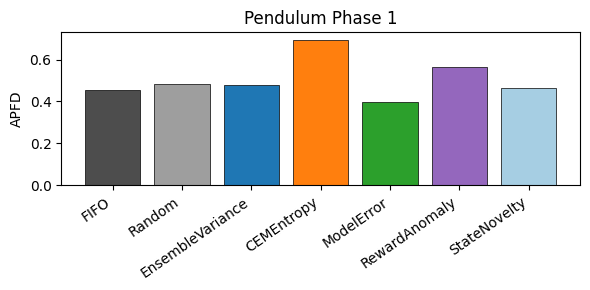

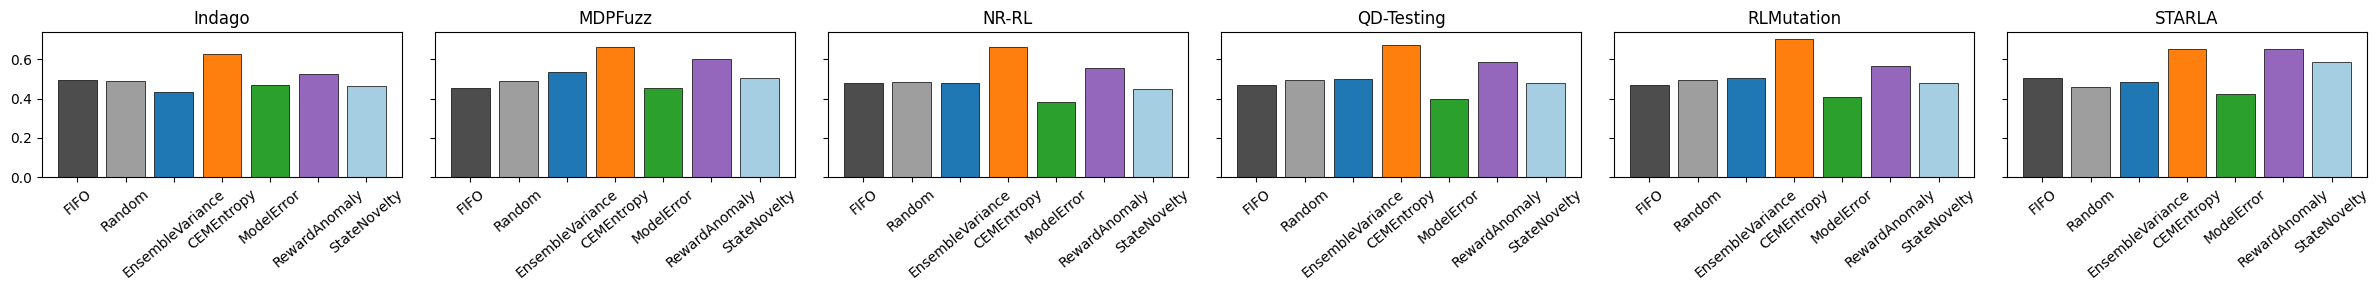

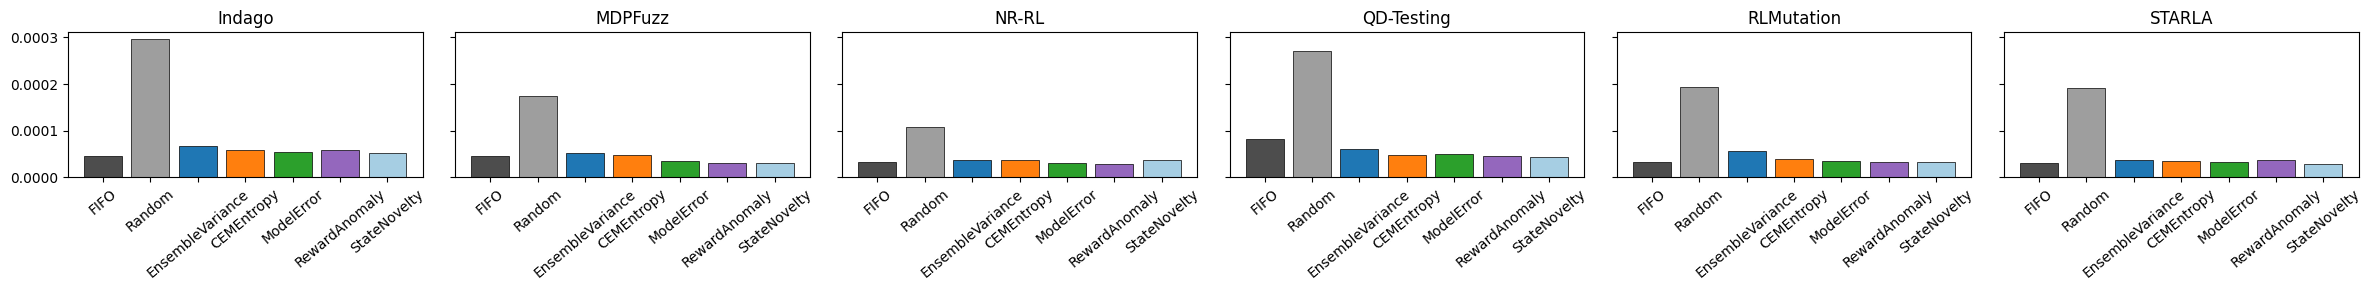


Tables : /content/drive/MyDrive/mbrl-testing-frameworks-empirical-study/results/pendulum_unified_tcp_full/tables
Figures: /content/drive/MyDrive/mbrl-testing-frameworks-empirical-study/results/pendulum_unified_tcp_full/figs


In [ ]:
# ==============================================================================
#  MAIN
# ==============================================================================

def main():

    print("=" * 70)
    print("PENDULUM TCP REPLICATION")
    print("=" * 70)

    print("\nRunning Phase 1...")

    phase1_results = (
        run_phase1()
    )

    phase1_agg = (
        summarize_phase1(
            phase1_results
        )
    )

    phase1_stats = (
        phase1_statistics(
            phase1_results
        )
    )

    print("\nRunning Phase 2...")

    phase2_results = (
        run_phase2()
    )

    phase2_agg = (
        summarize_phase2(
            phase2_results
        )
    )

    phase2_stats = (
        phase2_statistics(
            phase2_results
        )
    )

    print(
        "\nGenerating plots..."
    )

    plot_phase1_apfd(
        phase1_agg
    )

    plot_phase2_apfd(
        phase2_agg
    )

    plot_phase2_overhead(
        phase2_agg
    )

    print(
        f"\nTables : {TABLES_DIR}"
    )

    print(
        f"Figures: {FIGS_DIR}"
    )

    return {

        "phase1_results":
            phase1_results,

        "phase1_agg":
            phase1_agg,

        "phase1_stats":
            phase1_stats,

        "phase2_results":
            phase2_results,

        "phase2_agg":
            phase2_agg,

        "phase2_stats":
            phase2_stats,
    }


if __name__ == "__main__":

    outputs = main()